<div align='center'>
    <h1>Jurnal Praktikum Dasar Kecerdasan Artifisial</h1>
    <h3>Modul 8 & 9: Implementasi Hill Climbing dan Simulated Annealing</h3>
</div>

### Tujuan Praktikum
- Mahasiswa memahami dan mampu mengimplementasikan algoritma Hill Climbing pada python
- Mahasiswa memahami dan mampu mengimplementasikan algoritma Simulated Annealing pada python

**Jangan lupa untuk selalu import *library* Random ketika memulai sesi baru (*run time*) atau kode Python yang memerlukan penggunaan library Random**

In [1]:
print("'Aarif Rahmaan Jalaluddin Faqiih")  # Tuliskan nama lengkap Anda
print("103112430182")  # Tuliskan NIM Anda
print("IF-12-06")  # Tuliskan kelas Anda
print("https://colab.research.google.com/drive/1olsaN9UoqO1-y4P0dTTY3ZKEaBctaYM3?usp=sharing") # Link collab Praktikum
print("https://colab.research.google.com/drive/1vll44YtcD8MOpdNJzJz4avun22bjXPxd?usp=sharing") # Link collab Praktikum
print("https://colab.research.google.com/drive/1iVT6nW0CvdiaWDxmrXPPS4j-59SmIewa?usp=sharing") # Link collab Jurnal
print("https://github.com/aariffaqiih/CAK2HAB3-DASAR-KECERDASAN-ARTIFISIAL/tree/main/MODUL%2008%20IMPLEMENTASI%20HILL%20CLIMBING%20%26%2009%20IMPLEMENTASI%20SIMULATED%20ANNEALING") # Link collab Jurnal

'Aarif Rahmaan Jalaluddin Faqiih
103112430182
IF-12-06
https://colab.research.google.com/drive/1olsaN9UoqO1-y4P0dTTY3ZKEaBctaYM3?usp=sharing
https://colab.research.google.com/drive/1vll44YtcD8MOpdNJzJz4avun22bjXPxd?usp=sharing
https://colab.research.google.com/drive/1iVT6nW0CvdiaWDxmrXPPS4j-59SmIewa?usp=sharing
https://github.com/aariffaqiih/CAK2HAB3-DASAR-KECERDASAN-ARTIFISIAL/tree/main/MODUL%2008%20IMPLEMENTASI%20HILL%20CLIMBING%20%26%2009%20IMPLEMENTASI%20SIMULATED%20ANNEALING


In [2]:
# import random
import random # library ini akan digunakan untuk melakukan inisiasi solusi awal secara random
import pandas as pd # import pandas # library ini akan digunakan untuk mengolah data dalam bentuk tabel

def printJadwal(solusi):
    print(pd.DataFrame.from_dict(solusi, orient='index', columns=['Ruangan', 'Waktu']))

## Hill Climbing (40)

### Soal 1 (25)

SMA RezaSangar memiliki 9 mata pelajaran yang harus dijadwalkan untuk satu semester. Terdapat 3 ruang kelas yang tersedia dan setiap mata pelajaran harus dijadwalkan pada salah satu dari 4 waktu yang tersedia dalam seminggu.

**Syarat:**
- Tidak boleh ada dua mata pelajaran yang dijadwalkan pada waktu yang sama.
- Setiap mata pelajaran harus dijadwalkan tepat pada satu waktu dan satu ruang

**Final State:**
- Seluruh mata pelajaran telah dijadwalkan ke dalam ruangan dan waktu yang tersedia tanpa adanya bentrok

**Data mata pelajaran, ruang kelas, dan waktu yang tersedia**
|Mata Pelajaran|Ruang Kelas|Waktu|
|---|---|---|
|Ekonomi|Ruang 101|Senin 08:00|
|Geologi|Ruang 102|Senin 10:00|
|Sejarah|Ruang 103|Selasa 08:00|
|Fisika||Rabu 08:00|
|Biologi|||
|Kimia|||
|Matematika|||
|Bahasa Indonesia|||
|Bahasa Inggris|||

#### 1. (5 poin) Buat fungsi untuk mencari solusi awal

Hint: Solusi yang akan terbentuk adalah sebuah dictionary dengan `key berupa nama mata pelajaran` dan `value berupa tupple` ruang kelas dan waktu yang tersedia

**Pro tips:** gunakan fungsi `random.choice()` untuk memilih secara acak nilai dalam array

In [3]:
def initiateSolusiAwal(mapel, ruangan, waktu):
    solusi = {} # Buat sebuah dictionary kosong
    for mk in mapel: # Telusuri seluruh nilai dalam array mapel!
        # Key akan berupa nama mapel dan valuenya berupa tupple ruang kelas dan waktu yang tersedia
        solusi[mk] = (random.choice(ruangan), random.choice(waktu))
    return solusi

# Penjelasan

Kode ini berfungsi untuk membuat sebuah dictionary yang berisi penugasan mapel ke ruangan dan waktu secara acak. Pertama, sebuah dictionary kosong dibuat terlebih dahulu dengan nama variabel solusi, kemudian kode akan menelusuri seluruh nilai dalam array mapel satu per satu. Untuk setiap mapel yang ditemukan, kode akan membuat pasangan key dan value di mana key berupa nama mapel itu sendiri, sedangkan value berupa tupple yang terdiri dari dua elemen: ruang kelas yang dipilih secara acak dari daftar ruangan yang tersedia, dan waktu yang juga dipilih secara acak dari daftar waktu yang tersedia. Setelah seluruh mapel selesai diproses, dictionary yang sudah terisi tersebut akan dikembalikan sebagai hasil akhir.

#### 2. (5 poin) Buat fungsi untuk menghitung jumlah jadwal yang bentrok

**Pro tips:** kita dapat melakukan eksplorasi nilai dictionary dengan menggunakan loop berikut `for key, value in dict.items():`

In [4]:
def hitungBentrok(solusi):
    jumlahBentrok = 0 # inisiasi nilai awal jumlah jadwal yang bentrok dengan nilai 0
    jadwal = {} # buat dictionary kosong untuk menampung jadwal

    for mataKuliah, (ruangan, waktu) in solusi.items(): # Telusuri seluruh nilai dalam dictionary solusi
        key = (ruangan, waktu) # Tampung tupple yang ada pada dictionary
        if key in jadwal: # Cek apakah tupple ruangan dan waktu sudah ada di jadwal atau belum
            jumlahBentrok += 1 # Lakukan increment jumlah bentrok
        else:
            jadwal[key] = mataKuliah # isi key jadwal dengan tupple ruang dan waktu, dan value jadwal dengan nama mata pelajaran

    return jumlahBentrok

# Penjelasan

Fungsi hitungBentrok bekerja dengan cara menelusuri setiap pasangan mata pelajaran beserta ruangan dan waktunya yang tersimpan di dalam dictionary solusi. Di awal, nilai hitungan bentrok diisi dengan 0 dan dibuat dictionary kosong bernama jadwal untuk menampung data sementara. Setiap kali fungsi menemukan pasangan ruangan dan waktu, pasangan tersebut disusun sebagai key dan dicek apakah sudah pernah tersimpan di dictionary jadwal. Jika pasangan ruangan dan waktu itu sudah ada, artinya ada jadwal lain yang menggunakan ruangan dan waktu yang sama, maka hitungan bentrok ditambah 1. Tapi jika pasangan ruangan dan waktu belum ada di dictionary jadwal, maka pasangan tersebut disimpan dengan value berupa nama mata pelajaran. Setelah seluruh item di dictionary solusi selesai diperiksa, fungsi mengembalikan nilai total bentrok yang ditemukan.

#### 3. (5 poin) Buat fungsi untuk mencari tetangga

In [5]:
def cariTetangga(solusi, arrMapel, arrRuangan, arrWaktu):
    tetangga = [] # inisiasi tetangga dengan list kosong
    for pelajaran in arrMapel: # eksplorasi seluruh pelajaran pada list arrMapel
        currRuangan, currWaktu = solusi[pelajaran] # ambil nilai ruangan dan waktu saat ini pada dictionary solusi

         # coba untuk ganti ruangan
        for ruangan in arrRuangan: # eksplorasi seluruh ruangan pada list arrRuangan
            if ruangan != currRuangan: # buat percabangan jika ruangan tidak sama dengan currRuangan
                tetanggaBaru = solusi.copy()
                tetanggaBaru[pelajaran] = (ruangan, currWaktu) # buat tetangga baru berdasarkan ruangan baru yang telah ditemukan dan currentWaktu
                tetangga.append(tetanggaBaru) # tambah tetanggaBaru ke dalam list tetangga

        # coba untuk ganti waktu:
        for waktu in arrWaktu: # eksplorasi seluruh waktu pada list arrWaktu
            if waktu != currWaktu:  # buat percabangan jika waktu tidak sama dengan currWaktu
                tetanggaBaru = solusi.copy()
                tetanggaBaru[pelajaran] = (currRuangan, waktu) # buat tetangga baru berdasarkan waktu baru yang telah ditemukan dan currentRuangan
                tetangga.append(tetanggaBaru) # tambah tetanggaBaru ke dalam list tetangga

    return tetangga

# Penjelasan

Fungsi ini diberi nama cariTetangga dan menerima empat masukan yaitu solusi yang berupa dictionary, arrMapel yang berisi daftar pelajaran, arrRuangan yang berisi daftar ruangan, dan arrWaktu yang berisi daftar waktu. Di bagian paling awal fungsi ini, sebuah list kosong diberi nama tetangga untuk menampung hasil nantinya. Setelah itu, fungsi ini mulai menelusuri setiap pelajaran yang ada di dalam arrMapel. Untuk setiap pelajaran yang sedang diproses, fungsi ini mengambil pasangan ruangan dan waktu yang tersimpan di dictionary solusi, lalu menyimpannya ke dalam dua variabel yaitu currRuangan dan currWaktu.

Setelah mendapatkan informasi ruangan dan waktu saat ini, fungsi ini melakukan dua eksplorasi berbeda. Eksplorasi pertama adalah mencoba mengganti ruangan. Fungsi ini menelusuri seluruh ruangan yang ada di arrRuangan, dan untuk setiap ruangan yang berbeda dengan currRuangan, fungsi ini membuat salinan dari dictionary solusi. Di salinan tersebut, pelajaran yang sedang diproses diperbarui dengan pasangan ruangan baru dan waktu yang tetap sama. Hasil salinan ini kemudian dimasukkan ke dalam list tetangga.

Eksplorasi kedua adalah mencoba mengganti waktu. Cara kerjanya mirip dengan eksplorasi ruangan, yaitu fungsi ini menelusuri seluruh waktu di arrWaktu, dan untuk setiap waktu yang berbeda dengan currWaktu, fungsi ini lagi-lagi membuat salinan dictionary solusi. Di salinan tersebut, pelajaran yang sedang diproses diperbarui dengan pasangan ruangan yang tetap sama dan waktu yang baru. Hasil salinan ini juga dimasukkan ke dalam list tetangga.

Setelah seluruh pelajaran selesai diproses dengan kedua eksplorasi tersebut, fungsi ini mengembalikan list tetangga yang sudah terisi dengan berbagai variasi solusi baru. Setiap variasi solusi baru ini hanya berbeda pada satu aspek saja dari solusi asli, yaitu entah ruangannya yang diganti atau waktunya yang diganti, sehingga menghasilkan solusi-solusi tetangga yang berada di sekitar solusi awal.

#### 4. (10 poin) Mencari solusi dengan hill climbing

a. (2 poin) definisikan data berdasarkan soal yang berikan

In [6]:
mataPelajaran = ['Ekonomi', 'Geologi', 'Sejarah', 'Fisika', 'Biologi', 'Kimia', 'Matematika', 'Bahasa Indonesia', 'Bahasa Inggris'] # Inisiasikan list dengan nama mata pelajaran
ruangKelas = ['Ruang 101', 'Ruang 102', 'Ruang 103'] # Inisiasikan list dengan nama ruangan
waktu = ['Senin 08:00', 'Senin 10:00', 'Selasa 08:00', 'Rabu 08:00'] # Inisiasikan list dengan waktu yang tersedia

b. (3 poin) Buat solusi awal dan hitung berapa banyak jadwal yang bentrok

In [7]:
solusi = initiateSolusiAwal(mataPelajaran, ruangKelas, waktu) # deklarasikan solusi awal dengan menggunakan fungsi initiateSolusiAwal()
jumBentrok = hitungBentrok(solusi) # Hitung jumlah jadwal bentrok dengan fungsi hitungBentrok()
iterasi = 0

print(f"Iterasi: {iterasi}\nJumlah Bentrok: {jumBentrok}\nSolusi Awal:")
printJadwal(solusi)

Iterasi: 0
Jumlah Bentrok: 2
Solusi Awal:
                    Ruangan         Waktu
Ekonomi           Ruang 103  Selasa 08:00
Geologi           Ruang 102  Selasa 08:00
Sejarah           Ruang 101   Senin 10:00
Fisika            Ruang 101    Rabu 08:00
Biologi           Ruang 101   Senin 08:00
Kimia             Ruang 102    Rabu 08:00
Matematika        Ruang 102   Senin 08:00
Bahasa Indonesia  Ruang 102    Rabu 08:00
Bahasa Inggris    Ruang 102    Rabu 08:00


Contoh *output* <br>
**Output mungkin akan memberikan hasil yang berbeda karena dipilih secara acak**
<img src="./asset/1_output1.png" alt="Output 1" style="width: 50%; height: auto;">

c. (5 poin) Lakukan looping hingga jadwal bentrok habis atau tidak ada jumlah jadwal bentrok yang lebih baik daripada solusi saat ini

In [8]:
while True:
    tetangga = cariTetangga(solusi, mataPelajaran, ruangKelas, waktu) # cari tetangga solusi dengan menggunakan fungsi cariTetangga()

    jumlahBentrokTetangga = [] # inisiasi list kosong
    for solusiTetangga in tetangga: # telusuri seluruh kemungkinan tetangga yang sudah di dapatkan
        bentrokTetangga = hitungBentrok(solusiTetangga) # hitung jadwal bentrok tetangga dengan fungsi hitungBentrok()
        jumlahBentrokTetangga.append((solusiTetangga, bentrokTetangga)) # tambahkan tupple solusi dan jumlah bentrok kedalam list jumlahBentrokTetangga

    jumlahBentrokTetangga.sort(key=lambda x: x[1]) # melakukan sorting array berdasarkan nilai bentrok
    bestTetangga, bestBentrok = jumlahBentrokTetangga[0] # mengambil solusi dan jumlah bentrok terbaik

    if bestBentrok < jumBentrok: # buat pengkondisian apabila jumlah bentrok tetangga lebih kecil dari nilai jumlah bentrok saat ini
        solusi = bestTetangga # Assign nilai solusi menjadi solusi terbaik saat ini
        jumBentrok = bestBentrok # Assign nilai jumBentrok menjadi jumlah bentrok paling sedikit saat ini
        iterasi += 1 # increment iterasi
        print(f"\nIterasi: {iterasi}\nJumlah Bentrok: {jumBentrok}\nSolusi:")
        printJadwal(solusi)
        print("-"*50)
        if jumBentrok == 0: # percabangan jika jumlah bentrok sudah 0
            print("Solusi terbaik ditemukan")
            break
    else:
        print("Tidak ada tetangga yang lebih baik. Algoritma berhenti.")
        break

print("\nSolusi terbaik: ")
printJadwal(solusi)
print("Jumlah jadwal bentrok: ", jumBentrok)


Iterasi: 1
Jumlah Bentrok: 1
Solusi:
                    Ruangan         Waktu
Ekonomi           Ruang 103  Selasa 08:00
Geologi           Ruang 102  Selasa 08:00
Sejarah           Ruang 101   Senin 10:00
Fisika            Ruang 101    Rabu 08:00
Biologi           Ruang 101   Senin 08:00
Kimia             Ruang 103    Rabu 08:00
Matematika        Ruang 102   Senin 08:00
Bahasa Indonesia  Ruang 102    Rabu 08:00
Bahasa Inggris    Ruang 102    Rabu 08:00
--------------------------------------------------

Iterasi: 2
Jumlah Bentrok: 0
Solusi:
                    Ruangan         Waktu
Ekonomi           Ruang 103  Selasa 08:00
Geologi           Ruang 102  Selasa 08:00
Sejarah           Ruang 101   Senin 10:00
Fisika            Ruang 101    Rabu 08:00
Biologi           Ruang 101   Senin 08:00
Kimia             Ruang 103    Rabu 08:00
Matematika        Ruang 102   Senin 08:00
Bahasa Indonesia  Ruang 102   Senin 10:00
Bahasa Inggris    Ruang 102    Rabu 08:00
---------------------------------

# Penjelasan

Pertama-tama, kode ini membuat tiga list yang berisi data dasar. List pertama menyimpan nama-nama pelajaran mulai dari Ekonomi sampai Bahasa Inggris. List kedua berisi tiga nama ruangan yaitu Ruang 101, Ruang 102, dan Ruang 103. List ketiga mencatat waktu yang tersedia, ada empat slot waktu yang dimulai dari Senin pagi sampai Rabu pagi.

Setelah data siap, kode ini menjalankan fungsi `initiateSolusiAwal()` untuk membuat penjadwalan pertama. Hasilnya disimpan di variabel solusi. Kemudian dihitung berapa jadwal bentrok yang terjadi menggunakan fungsi `hitungBentrok()`. Variabel iterasi di-set mulai dari nol untuk mencatat berapa kali proses perbaikan dilakukan.

Kode ini menampilkan kondisi awal: nomor iterasi, jumlah bentrok yang ada, serta menunjukkan isi jadwal dengan fungsi `printJadwal()`.

Kode ini menggunakan loop `while True` yang berjalan terus sampai kondisi berhenti terpenuhi. Di dalam loop, langkah-langkahnya adalah:

1. Fungsi `cariTetangga()` di untuk mencari kemungkinan jadwal lain yang mirip dengan solusi sekarang tapi dengan perubahan kecil.

2. Untuk tiap kemungkinan tetangga, dihitung jumlah bentroknya. Hasilnya disimpan sebagai pasangan (solusi tetangga, jumlah bentrok) di dalam list.

3. List diurutkan berdasarkan jumlah bentrok terkecil. Tetangga dengan bentrok paling sedikit diambil sebagai bestTetangga.

4. Jika tetangga terbaik punya bentrok lebih sedikit dari solusi sekarang:
   - Solusi diperbarui dengan tetangga terbaik
   - Jumlah bentrok diperbarui
   - Iterasi ditambah satu
   - Hasil baru ditampilkan
   - Jika sudah tidak ada bentrok sama sekali (nol), proses berhenti dan dinyatakan solusi terbaik sudah ditemukan

   Jika tidak ada tetangga yang lebih baik, proses berhenti dengan pesan bahwa algoritma tidak bisa melanjutkan.

Contoh *output* <br>
**Output mungkin akan memberikan hasil yang berbeda karena dipilih secara acak**
<img src="./asset/2_output2.png" alt="Output 2" style="width: 50%; height: auto;">

### Soal 2 (15)

SMA RezaHaHaHa memiliki 9 mata pelajaran yang harus dijadwalkan untuk satu semester. Terdapat 3 ruang kelas yang tersedia dan setiap mata pelajaran harus dijadwalkan pada salah satu dari 4 waktu yang tersedia dalam seminggu.

**Syarat:**
- Tidak boleh ada dua mata pelajaran yang dijadwalkan pada waktu yang sama.
- Setiap mata pelajaran harus dijadwalkan tepat pada satu waktu dan satu ruang
- ada beberapa mata pelajaran yang harus `diambil terlebih dahulu` sebelum mata pelajaran tertentu

**Final State:**
- Seluruh mata pelajaran telah dijadwalkan ke dalam ruangan dan waktu yang tersedia tanpa adanya bentrok dan sudah sesuai dengan syarat pengambilan mata pelajaran

**Data mata pelajaran, ruang kelas, dan waktu yang tersedia**
|Mata Pelajaran|Ruang Kelas|Waktu|
|---|---|---|
|Logika Matematika|Ruang 101|Senin 08:00|
|Matematika Diskrit|Ruang 102|Senin 10:00|
|Kalkulus|Ruang 103|Selasa 08:00|
|Kalkulus Lanjut||Rabu 08:00|
|Agama|||
|Pendidikan Karakter|||
|Biologi|||
|Kimia|||
|Fisika|||

**Syarat tambahan**
- Mata pelajaran `Kalkulus Lanjut` harus diambil setelah mata pelajaran `Kalkulus`
- Mata pelajaran `Matematika Diskrit` harus diambil setelah mata pelajaran `Logika Matematika`

Pro tips: ketiga fungsi sebelumnya, namun `buat ulang fungsi hitungBentrok` dan tambahkan algoritma untuk memeriksa urutan mata pelajaran

In [9]:
# Buat ulang hitungBentrok, ketika urutan_mata_pelajaran salah maka bentrok akan di increment
def hitungBentrok(solusi, urutan_mata_pelajaran):
    jumlahBentrok = 0 # inisiasi nilai awal jumlah jadwal yang bentrok dengan nilai 0
    jadwal = {} # buat dictionary kosong untuk menampung jadwal

    # Urutan waktu dari paling awal ke paling akhir
    urutan_waktu = ['Senin 08:00', 'Senin 10:00', 'Selasa 08:00', 'Rabu 08:00']

    for mataKuliah, (ruangan, waktu) in solusi.items(): # Telusuri seluruh nilai dalam dictionary solusi
        key = (ruangan, waktu) # Tampung tupple yang ada pada dictionary
        if key in jadwal: # Cek apakah tupple ruangan dan waktu sudah ada di jadwal atau belum
            jumlahBentrok += 1 # Lakukan increment jumlah bentrok
        else:
            jadwal[key] = mataKuliah # isi key jadwal dengan tupple ruang dan waktu, dan value jadwal dengan nama mata pelajaran

        # Periksa urutan mata pelajaran
        for prerequisit in urutan_mata_pelajaran.get(mataKuliah, []): # ambil daftar mata pelajaran yang menjadi prasyarat
            if urutan_waktu.index(solusi[prerequisit][1]) >= urutan_waktu.index(waktu):  # Jika prerequisit diajarkan setelah mata pelajaran ini
                jumlahBentrok += 1

    return jumlahBentrok

In [10]:
# Inisiasi data
mataPelajaran = ['Logika Matematika', 'Matematika Diskrit', 'Kalkulus', 'Kalkulus Lanjut', 'Agama', 'Pendidikan Karakter', 'Biologi', 'Kimia', 'Fisika'] # Inisiasikan list dengan nama mata pelajaran
ruangKelas = ['Ruang 101', 'Ruang 102', 'Ruang 103'] # Inisiasikan list dengan nama ruangan
waktu = ['Senin 08:00', 'Senin 10:00', 'Selasa 08:00', 'Rabu 08:00'] # Inisiasikan list dengan waktu yang tersedia

urutan_mata_pelajaran = { # Inisiasikan dictionary dengan urutan mata pelajaran
    'Kalkulus Lanjut': ['Kalkulus'], # Kalkulus Lanjut harus diambil setelah Kalkulus
    'Matematika Diskrit': ['Logika Matematika'], # Matematika Diskrit harus diambil setelah Logika Matematika
}

In [11]:
# Buat dan tampilkan solusi pertama
solusi = initiateSolusiAwal(mataPelajaran, ruangKelas, waktu) # Inisialisasi solusi awal
jumBentrok = hitungBentrok(solusi, urutan_mata_pelajaran) # Hitung jumlah bentrok
iterasi = 0 # Inisialisasi iterasi

print(f"Iterasi: {iterasi}\nJumlah Bentrok: {jumBentrok}\nSolusi Awal:")
printJadwal(solusi)

Iterasi: 0
Jumlah Bentrok: 4
Solusi Awal:
                       Ruangan         Waktu
Logika Matematika    Ruang 102    Rabu 08:00
Matematika Diskrit   Ruang 103   Senin 10:00
Kalkulus             Ruang 103    Rabu 08:00
Kalkulus Lanjut      Ruang 101   Senin 10:00
Agama                Ruang 101   Senin 10:00
Pendidikan Karakter  Ruang 101  Selasa 08:00
Biologi              Ruang 101   Senin 08:00
Kimia                Ruang 102   Senin 08:00
Fisika               Ruang 101  Selasa 08:00


Contoh *output* <br>
**Output mungkin akan memberikan hasil yang berbeda karena dipilih secara acak**
<img src="./asset/3_output3.png" alt="Output 3" style="width: 50%; height: auto;">

In [12]:
while True:
    tetangga = cariTetangga(solusi, mataPelajaran, ruangKelas, waktu) # cari tetangga solusi dengan menggunakan fungsi cariTetangga()

    jumlahBentrokTetangga = [] # inisiasi list kosong
    for solusiTetangga in tetangga:
        bentrokTetangga = hitungBentrok(solusiTetangga, urutan_mata_pelajaran) # hitung bentrok dengan mempertimbangkan urutan mata kuliah
        jumlahBentrokTetangga.append((solusiTetangga, bentrokTetangga))

    jumlahBentrokTetangga.sort(key=lambda x: x[1])
    bestTetangga, bestBentrok = jumlahBentrokTetangga[0] # mengambil solusi dan jumlah bentrok terbaik (inisiasi awal)

    if bestBentrok < jumBentrok: # buat pengkondisian apabila jumlah bentrok tetangga lebih kecil dari nilai jumlah bentrok saat ini
        solusi = bestTetangga # Assign nilai solusi menjadi solusi terbaik saat ini
        jumBentrok = bestBentrok # Assign nilai jumBentrok menjadi jumlah bentrok paling sedikit saat ini
        iterasi += 1
        print(f"\nIterasi: {iterasi}\nJumlah Bentrok: {jumBentrok}\nSolusi:")
        printJadwal(solusi)
        print("-"*50)

        if jumBentrok == 0: # percabangan jika jumlah bentrok sudah 0
            print("Solusi terbaik ditemukan")
            break
    else:
        print("Tidak ada tetangga yang lebih baik. Algoritma berhenti.")
        break

print("\nSolusi terbaik:")
printJadwal(solusi)
print("Jumlah jadwal bentrok: ", jumBentrok)


Iterasi: 1
Jumlah Bentrok: 3
Solusi:
                       Ruangan         Waktu
Logika Matematika    Ruang 102    Rabu 08:00
Matematika Diskrit   Ruang 103   Senin 10:00
Kalkulus             Ruang 103   Senin 08:00
Kalkulus Lanjut      Ruang 101   Senin 10:00
Agama                Ruang 101   Senin 10:00
Pendidikan Karakter  Ruang 101  Selasa 08:00
Biologi              Ruang 101   Senin 08:00
Kimia                Ruang 102   Senin 08:00
Fisika               Ruang 101  Selasa 08:00
--------------------------------------------------

Iterasi: 2
Jumlah Bentrok: 2
Solusi:
                       Ruangan         Waktu
Logika Matematika    Ruang 102    Rabu 08:00
Matematika Diskrit   Ruang 103   Senin 10:00
Kalkulus             Ruang 103   Senin 08:00
Kalkulus Lanjut      Ruang 102   Senin 10:00
Agama                Ruang 101   Senin 10:00
Pendidikan Karakter  Ruang 101  Selasa 08:00
Biologi              Ruang 101   Senin 08:00
Kimia                Ruang 102   Senin 08:00
Fisika            

# Penjelasan

Fungsi ini punya tugas menghitung seberapa banyak jadwal yang bentrok atau tidak sesuai aturan.

Yang dilakukan fungsi ini:

1. Cek bentrok ruang-waktu - Kalau ada 2 mata pelajaran menggunakan ruangan dan waktu yang sama, itu bentrok
2. Cek urutan prasyarat - Kalau Kalkulus Lanjut dijadwalkan sebelum Kalkulus, itu juga bentrok

Di sini kita punya:
- 9 mata pelajaran
- 3 ruang kelas
- 4 slot waktu
- Aturan: Kalkulus Lanjut harus setelah Kalkulus, Matematika Diskrit harus setelah Logika Matematika

Algoritma Hill Climbing:

1. Cari tetangga (solusi yang mirip tapi ada 1 perubahan kecil)
2. Hitung bentrok semua tetangga
3. Pilih tetangga dengan bentrok paling sedikit
4. Kalau lebih baik dari solusi sekarang, pindah ke sana
5. Ulangi sampai bentrok 0 atau tidak ada yang lebih baik

Contoh *output* <br>
**Output mungkin akan memberikan hasil yang berbeda karena dipilih secara acak**
<img src="./asset/4_output4.png" alt="Output 4" style="width: 50%; height: auto;">

## Simulated Annealing (60)

**Jangan lupa untuk selalu import *library* ketika memulai sesi baru (*run time*) atau kode Python yang memerlukan penggunaan library**

In [13]:
import random
import math
import numpy as np
import matplotlib.pyplot as plt

### Soal Cerita

Ekspedisi SiReza memiliki 1 kantor pusat dan beberapa lokasi pelanggan yang harus dikunjungi untuk pengiriman barang. Setiap pelanggan memiliki permintaan barang yang berbeda, dan setiap kendaraan memiliki kapasitas maksimum yang dapat diangkut.

**Tujuan:**
- Semua pelanggan berhasil dilayani
- Total jarak tempuh kendaraan atau biaya operasional dapat diminimalkan
- Kapasitas kendaraan tidak terlampaui

**Data Perusahaan Ekspedisi:**
- Kantor pusat berada di koordinat `(50,50)`
- Jumlah kendaraan yang bisa digunakan adalah `3`
- Kapasitas tiap kendaraan adalah `100`

**Data Pelanggan:**
|ID Pelanggan|Koordinat X|Koordinat Y|Kapasitas yang dibutuhkan|
|---|---|---|---|
|Cust-1001|10|20|10|
|Cust-1002|15|25|15|
|Cust-1003|20|30|20|
|Cust-1004|35|35|25|
|Cust-1005|40|40|30|
|Cust-1006|45|45|35|
|Cust-1007|50|55|40|
|Cust-1008|55|60|45|
|Cust-1009|60|65|50|
|Cust-1010|65|70|55|

**Penting! :**

**`Hint:`**
Banyak function yang menggunakan parameter dengan nama yang sama seperti
- arrCust merupakan array customer yang memiliki data berbentuk list yang berisi banyak tupple, berikut contoh dari datanya:

        arrCust = [
            (customerID, X, Y, Kapasitas),
            (customerID, X, Y, Kapasitas)
        ]

- routes akan berisi rute yang dilewati oleh ketiga kendaraan data tersebut akan berupa list yang memiliki 3 list didalamnya, berikut contoh dari datanya:

        routes = [
            [customerID, customerID, customerID],
            [customerID, customerID],
            [customerID, customerID, customerID, customerID]
        ]

#### 1. (5 poin) Buat fungsi untuk menghitung jarak euclidean

Jarak Euclidean antara dua titik, (x₁, y₁) dan (x₂, y₂), dihitung dengan rumus berikut:

```math
d(x₁, y₁, x₂, y₂) = \sqrt{(x₂ - x₁)^2 + (y₂ - y₁)^2}
````

Pro tips: gunakan `math.sqrt()` untuk menghitung akar.

In [14]:
# Input berupa 2 tupple koordinat
def jarakEuclidean(a, b):
    return math.sqrt((b[0] - a[0])**2 + (b[1] - a[1])**2) # hitung dengan menggunakan rumus jarak euclidean

# Penjelasan

Fungsi ini menghitung jarak antara dua titik di bidang datar. Caranya, fungsi ini terima dua masukan berupa tupple koordinat - tupple pertama buat titik awal, tupple kedua buat titik tujuan.

Di dalam fungsi ini, langkah yang dilakukan adalah:
1. Ambil nilai x dari titik b, lalu kurangi dengan nilai x dari titik a
2. Hasil pengurangan itu dikuadratkan
3. Lakukan hal yang sama buat nilai y - ambil y dari titik b, kurangi y dari titik a, lalu kuadratkan
4. Jumlahkan kedua hasil kuadrat tadi
5. Terakhir, ambil akar dari total penjumlahan tersebut dengan `math.sqrt`

#### 2. (5 poin) Buat fungsi untuk mencari customer berdasarkan customer id

In [15]:
def cariPelanggan(customerID, arrCust):
    for cust in arrCust: # Telusuri seluruh customer dalam list customers
        if cust[0] == customerID: # Periksa apakah index pertama cust sama dengan customer id
            return cust # Kembalikan nilai dari cust
    return None # kembalikan None Jika tidak ditemukan pelanggan

# Penjelasan

Pertama, fungsi ini menerima dua masukan: satu berupa ID pelanggan yang mau dicari, dan satu lagi berupa list yang berisi data pelanggan-pelanggan yang sudah tersimpan.
Kemudian, kode ini akan melihat satu per satu data pelanggan yang ada di dalam list tersebut. Proses ini dilakukan dengan menggunakan perulangan for yang akan mengecek setiap elemen di dalam arrCust.
Setiap kali mengecek satu data pelanggan, kode ini akan membandingkan apakah ID pelanggan di index pertama dari data tersebut cocok dengan ID yang sedang dicari. Jika cocok, maka data pelanggan tersebut langsung dikembalikan sebagai hasil.
Jika sudah dicek semua tapi tidak ada yang cocok, maka fungsi ini akan mengembalikan nilai None yang berarti data pelanggan tersebut tidak ditemukan di dalam list.

#### 3. (10 poin) Buat fungsi untuk menghitung jarak keseluruhan dalam list routes

In [16]:
def totalJarak(routes, pusat, arrCust):
    distance = 0 # set jarak awal
    for route in routes: # telusuri seluruh rute pada routes
        if len(route) == 0: # buat percabangan jika tidak ada pelanggan pada route
            continue # skip iterasi ini ke iterasi selanjutnya

        # Mulai dari pusat
        prev = pusat # inisiasi prev dengan koordinat kantor pusat
        for customerID in route: # telusuri seluruh customer dalam route
            customer = cariPelanggan(customerID, arrCust) # cari customer berdasarkan customerID dalam array customer
            if customer is None: # Biarkan NONE!!
                continue # skip iterasi ini ke iterasi selanjutnya
            current = (customer[1], customer[2]) # deklarasi lokasi saat ini berdasarkan koordinat customer yang telah ditemukan
            distance += jarakEuclidean(prev, current) # hitung jarak saat ini dan jarak cust
            prev = current # perbarui lokasi prev dengan lokasi saat ini
        distance += jarakEuclidean(prev, pusat) # hitung jarak kendaraan untuk kembali ke kantor pusat
    return distance

# Penjelasan

Pertama, fungsi ini menerima tiga input: routes yang berisi daftar rute perjalanan, pusat yang merupakan koordinat lokasi kantor pusat, dan arrCust yang berisi data seluruh pelanggan.
Variabel distance diatur ke 0 di awal untuk menyimpan akumulasi jarak total. Kemudian, setiap rute dalam routes akan dicek satu per satu. Jika suatu rute kosong, iterasi akan dilewati ke rute berikutnya.
Untuk setiap rute yang memiliki pelanggan, perhitungan dimulai dari kantor pusat. Variabel prev diisi dengan koordinat pusat sebagai titik awal. Setelah itu, setiap ID pelanggan dalam rute akan dicari datanya menggunakan fungsi cariPelanggan. Jika pelanggan tidak ditemukan, iterasi dilewati.
Ketika pelanggan ditemukan, koordinatnya disimpan di current. Jarak antara prev dan current dihitung menggunakan fungsi jarakEuclidean, lalu hasilnya ditambahkan ke distance. Lokasi prev kemudian diperbarui dengan current untuk iterasi berikutnya.
Setelah semua pelanggan dalam satu rute selesai dihitung, jarak dari lokasi terakhir pelanggan kembali ke kantor pusat juga ditambahkan ke distance. Ini memastikan kendaraan dihitung pergi dan pulang.

#### 4. (5 poin) Buat fungsi untuk melakukan validasi kapasitas pada list routes

In [17]:
def validateRoute(routes, arrCust, kapasitasMax):
    for route in routes: # telusuri seluruh route pada routes
        total = 0 # inisiasi kapasitas
        for customerID in route: # telusuri seluruh customer dalam route
            customer = cariPelanggan(customerID, arrCust) # cari customer berdasarkan customerID dalam array customer
            if customer is not None: # buat percabangan jika customer ditemukan atau tidak None
                total += customer[3] # jumlahkan kapasitas yang dibutuhkan customer
        if total > kapasitasMax: # cek apakah total sudah melebihi kapasitas maksimum atau belum
            return False # apabila total sudah melebihi kapasitas maksimum maka validate akan mengembalikan nilai False
    return True # Kembalikan nilai boolean True

# Penjelasan

Pertama, fungsi ini menerima 3 parameter: routes (daftar rute), arrCust (array data pelanggan), dan kapasitasMax (batas kapasitas tertinggi). Kemudian, fungsi ini mulai menelusuri seluruh rute yang ada di dalam routes menggunakan perulangan for.
Di dalam setiap rute, variabel total diinisiasi dengan nilai 0 untuk menyimpan jumlah kapasitas sementara. Setelah itu, fungsi menelusuri setiap customerID yang ada di dalam rute tersebut. Untuk setiap ID pelanggan, fungsi memanggil cariPelanggan untuk mencari data pelanggan yang cocok di dalam arrCust.
Jika pelanggan ditemukan (tidak None), maka kapasitas pelanggan yang berada di indeks ke-3 dari data pelanggan ditambahkan ke variabel total. Setelah seluruh pelanggan di dalam satu rute selesai dihitung, fungsi membandingkan total dengan kapasitasMax. Jika total sudah melebihi kapasitasMax, maka fungsi langsung mengembalikan nilai boolean False.
Tapi jika seluruh rute sudah dicek dan tidak ada yang melebihi batas kapasitas, maka fungsi mengembalikan nilai boolean True di akhir.

#### 5. (10 poin) Buat fungsi untuk melakukan inisiasi solusi awal

In [18]:
def inisiasiSolusiAwal(jumlahKendaraan, arrCust, kapasitasMaksimum):
    routes = [] # deklarasi rute dengan list kosong
    for i in range(jumlahKendaraan): # buat for loop sebanyak jumlah kendaraan
        routes.append([]) # tambahkan list kosong kedalam list routes untuk menampung data rute pada kendaraan

    shuffleCust = [] # deklarasi list kosong
    for cust in arrCust: # telusuri seluruh customer dalam arrCust
        shuffleCust.append(cust[0]) # tambahkan customer ID kedalam shuffle cust
    random.shuffle(shuffleCust) # acak list id customer dengan menggunakan fungsi random.shuffle()

    for customerID in shuffleCust: # telusuri seluruh customer id dalam list shuffleCust
        customer = cariPelanggan(customerID, arrCust) # cari customer berdasarkan customer id
        placed = False # inisiasi bahwa customer ini belum ada kendaraan yang mengantar
        for route in routes: # telusuri seluruh route dalam routes
            total = sum(next(c for c in arrCust if c[0] == cid)[3] for cid in route)
            if total + customer[3] <= kapasitasMaksimum: # buat percabangan apakah kapasitas kendaraan bisa menampung seluruh kapasitas yang dibutuhkan customer
                route.append(customerID) # tambahkan customer id kedalam list route
                placed = True # ubah placed menjadi True karena kita sudah memasukkan customer tersebut kedalam list route
                break # keluar dari loop routes
        if not placed: # buat percabangan jika placed belum True
            routes[0].append(customerID) # tampung customer ID ke list routes pada index pertama
    return routes

# Penjelasan

Pertama, buat list kosong untuk menampung rute tiap kendaraan. Loop dilakukan sebanyak jumlah kendaraan, dan tiap iterasi menambahkan list kosong ke dalam routes. Hasilnya adalah struktur data seperti [[], [], [], ...] sesuai jumlah kendaraan.
Kemudian, siapkan list ID pelanggan dalam urutan acak. List shuffleCust diisi dengan ID pelanggan dari arrCust, lalu diacak menggunakan random.shuffle(). Ini memberikan variasi dalam pembagian rute.
Setelah itu, sebar tiap pelanggan ke kendaraan yang cocok. Tiap ID pelanggan diproses satu per satu:

- Cari data pelanggan penuh lewat fungsi cariPelanggan

- Hitung total muatan yang sudah ada di tiap rute

- Jika muatan baru masih muat dalam batas maksimum, masukkan pelanggan ke rute tersebut

- Tandai bahwa pelanggan sudah ditempatkan dengan mengubah placed jadi True

Jika pelanggan tidak muat di kendaraan mana pun, paksa masuk ke rute pertama (index 0) sebagai fallback.
Akhirnya, kembalikan list routes yang berisi pembagian pelanggan per kendaraan.

#### 6. (10 poin) Buat fungsi untuk mencari tetangga

In [19]:
def cariTetangga(routes, arrCust, kapasitasMax):
    # Salin rute saat ini
    new_routes = [] # inisiasi rute baru dengan list kosong
    for route in routes: # telusuri seluruh route dalam list routes
        new_routes.append(route.copy()) # tambahkan route kedalam list new routes

    # ambil 2 route secara random yang akan kita coba tukar customernya dengan menggunakan random.sample()
    route1, route2 = random.sample(range(len(new_routes)), 2)
    if len(new_routes[route1]) == 0 or len(new_routes[route2]) == 0: # periksa apakah kedua route memiliki rute atau tidak
        return new_routes # jika kendaraan tidak memiliki rute maka tidak ada yang ditukar, fungsi akan langsung mengembalikan nilai rute yang sama

    # Pilih dua pelanggan secara acak dari rute yang berbeda dengan menggunakan fungsi random.choice()
    cust1 = random.choice(new_routes[route1])
    cust2 = random.choice(new_routes[route2])

    # Tukar pelanggan customer 1 pada route 1 dipindahkan ke route 2 dan sebaliknya
    new_routes[route1].remove(cust1)
    new_routes[route2].remove(cust2)
    new_routes[route1].append(cust2)
    new_routes[route2].append(cust1)

    if validateRoute(new_routes, arrCust, kapasitasMax): # validasi apakahh rute tidak melebihi kapasitas maksimum
        return new_routes
    else:
        return routes

# Penjelasan

Pertama, salin rute yang sudah ada terlebih dahulu agar data asli tidak berubah, setelah itu buat list kosong untuk menampung rute baru, kemudian telusuri seluruh rute dalam list routes, dan tambahkan salinan setiap rute ke dalam list baru.
Dari sini, ambil 2 rute secara acak yang akan dicoba untuk ditukar pelanggannya, tapi periksa dulu apakah kedua rute tersebut memiliki pelanggan atau tidak. Jika salah satu rute kosong, maka tidak ada yang ditukar dan fungsi akan langsung mengembalikan nilai rute yang sama.
Setelah itu, pilih dua pelanggan secara acak dari rute yang berbeda, kemudian lakukan pertukaran - pelanggan dari rute pertama dipindahkan ke rute kedua dan sebaliknya.
Maka dari itu, perlu dilakukan pengecekan apakah rute baru ini masih memenuhi batas kapasitas kendaraan. Jika hasil pengecekan lolos, fungsi akan mengembalikan rute baru yang sudah ditukar. Jika tidak lolos, fungsi akan mengembalikan rute asli tanpa perubahan.

#### 7. (10 poin) Buat algoritma Simulated Annealing

In [20]:
def simulated_annealing(jumlahKendaraan, arrCust, kapasitasMaksimum, pusat):
    # Inisiasi nilai awal dan jarak awal
    currentSolution = inisiasiSolusiAwal(jumlahKendaraan, arrCust, kapasitasMaksimum)
    currentCost = totalJarak(currentSolution, pusat, arrCust)

    # Tentukan best solution dan best Cost saat ini
    bestSolution = currentSolution
    bestCost = currentCost

    T = 1000  # Temperatur awal
    T_min = 1  # Temperatur minimum
    alpha = 0.995  # Faktor pendinginan

    while T > T_min:
        for _ in range(100):
            newSolution = cariTetangga(currentSolution, arrCust, kapasitasMaksimum) # cari solusi baru dengan menggunakan fungsi cariTetangga()
            newCost = totalJarak(newSolution, pusat, arrCust) # hitung total jarak solusi baru menggunakan fungsi totalJarak()

            delta = newCost - currentCost # selisih cost baru dengan cost lama
            if delta < 0 or random.uniform(0,1) < math.exp(-delta / T): # Jika memenuhi kondisi ini maka current solusi akan kita update
                currentSolution = newSolution
                currentCost = newCost

                if newCost < bestCost: # Tentukan apakah cost baru merupakan cost terkecil
                    # Update best solution dan best cost
                    bestSolution = newSolution
                    bestCost = newCost
        T *= alpha # temperature akan turun bergantung pada alpha
    return bestSolution, bestCost

# Penjelasan

Kode ini adalah implementasi algoritma **Simulated Annealing** untuk menyelesaikan masalah optimasi rute kendaraan (Vehicle Routing Problem).

### Bagian Pertama: Inisiasi Nilai Awal

```python
currentSolution = inisiasiSolusiAwal(jumlahKendaraan, arrCust, kapasitasMaksimum)
currentCost = totalJarak(currentSolution, pusat, arrCust)
```

Baris pertama memanggil fungsi `inisiasiSolusiAwal` untuk membuat solusi awal berdasarkan jumlah kendaraan, daftar pelanggan, dan kapasitas maksimum setiap kendaraan. Baris kedua menghitung total jarak dari solusi awal tersebut dengan memanggil fungsi `totalJarak` yang menerima solusi, lokasi pusat, dan daftar pelanggan.

### Bagian Kedua: Menyimpan Solusi Terbaik

```python
bestSolution = currentSolution
bestCost = currentCost
```

Di sini, solusi dan cost saat ini disimpan sebagai solusi terbaik sementara. Ini bertujuan agar kita punya patokan untuk membandingkan solusi-solusi berikutnya.

### Bagian Ketiga: Parameter Temperatur

```python
T = 1000  # Temperatur awal
T_min = 1  # Temperatur minimum
alpha = 0.995  # Faktor pendinginan
```

Tiga variabel ini mengatur proses pendinginan. `T` dimulai dari 1000 dan akan turun perlahan sampai mencapai `T_min` yang bernilai 1. Nilai `alpha` sebesar 0.995 menentukan seberapa cepat temperatur turun - semakin mendekati 1, prosesnya semakin lambat.

### Bagian Keempat: Loop Utama

```python
while T > T_min:
    for _ in range(100):
```

Loop luar berjalan selama temperatur masih di atas nilai minimum. Di dalamnya ada loop dalam yang berjalan 100 kali untuk setiap nilai temperatur. Ini bertujuan agar algoritma punya cukup kesempatan mengeksplorasi solusi pada setiap tingkat temperatur.

### Bagian Kelima: Mencari Solusi Baru

```python
newSolution = cariTetangga(currentSolution, arrCust, kapasitasMaksimum)
newCost = totalJarak(newSolution, pusat, arrCust)
delta = newCost - currentCost
```

Fungsi `cariTetangga` menghasilkan solusi baru dengan memodifikasi solusi saat ini. Setelah itu, total jarak solusi baru dihitung. Variabel `delta` menyimpan selisih antara cost baru dan cost lama.

### Bagian Keenam: Kriteria Penerimaan

```python
if delta < 0 or random.uniform(0,1) < math.exp(-delta / T):
    currentSolution = newSolution
    currentCost = newCost
```

Kondisi ini memutuskan apakah solusi baru diterima. Ada dua kemungkinan diterima: pertama, jika `delta` negatif (berarti solusi baru lebih baik), atau kedua, jika bilangan acak antara 0 dan 1 lebih kecil dari `e^(-delta/T)`. Peluang kedua ini memungkinkan algoritma menerima solusi yang lebih buruk, terutama saat temperatur masih tinggi.

### Bagian Ketujuh: Update Solusi Terbaik

```python
if newCost < bestCost:
    bestSolution = newSolution
    bestCost = newCost
```

Jika solusi baru ternyata lebih baik dari solusi terbaik yang pernah ditemukan, maka solusi terbaik diperbarui.

### Bagian Kedelapan: Penurunan Temperatur

```python
T *= alpha
```

Temperatur dikalikan dengan `alpha` (0.995), sehingga turun sedikit demi sedikit. Ini membuat peluang menerima solusi buruk semakin kecil seiring berjalannya waktu.

### Bagian Terakhir: Hasil Akhir

```python
return bestSolution, bestCost
```

Fungsi mengembalikan solusi terbaik yang ditemukan beserta total jaraknya.

#### 8. (5 poin) Buat main untuk mencari solusi terbaik dengan menggunakan fungsi yang telah dibangun

a. (2 poin) inisiasi data berdasarkan soal cerita diatas

In [21]:
# Koordinat kantor pusat
kantorPusat = (50, 50) # inisialisasi koordinat kantor pusat

# Data Pelanggan adalah list berisi tupple seperti tupple berikut (ID, X, Y, Permintaan)
arrCust = [
    ('Cust-1001', 10, 20, 10),
    ('Cust-1002', 15, 25, 15),
    ('Cust-1003', 20, 30, 20),
    ('Cust-1004', 35, 35, 25),
    ('Cust-1005', 40, 40, 30),
    ('Cust-1006', 45, 45, 35),
    ('Cust-1007', 50, 55, 40),
    ('Cust-1008', 55, 60, 45),
    ('Cust-1009', 60, 65, 50),
    ('Cust-1010', 65, 70, 55),
]

# jumlah kendaraan
jumlahKendaraan = 3 # inisialisasi jumlah kendaraan

# kapasitas maksimum kendaraan
kapasitasMaksimum = 100 # inisialisasi kapasitas maksimum kendaraan

b. (1 poin) cari solusi terbaik dan tampilkan solusi tersebut

In [22]:
# Panggil fungsi yang sudah kalian buat untuk mencari best routes dan best distance
best_routes, best_distance = simulated_annealing(jumlahKendaraan, arrCust, kapasitasMaksimum, kantorPusat) # panggil fungsi simulated_annealing()
# Print rute terbaik
print("Rute Terbaik:")

# lakukan loop untuk menelusuri rute terbaik sebanyak rute terbaik
for i in range(len(best_routes)):
    # print kendaraan
    print(f"Kendaraan {i+1}:", end=" kantor pusat -> ")

    # lakukan loop untuk menelusuri customer id dari rute terbaik
    for j in range(len(best_routes[i])):
        # tampilkan customer id nya
        print(best_routes[i][j], end=" -> ")

    # kendaraan akan kembali ke kantor pusat maka print kantor pusat
    print("kantor pusat")

# print jarak rute terbaik
print("\nJarak Rute Terbaik: ", best_distance)

Rute Terbaik:
Kendaraan 1: kantor pusat -> Cust-1001 -> Cust-1008 -> Cust-1005 -> Cust-1007 -> Cust-1004 -> kantor pusat
Kendaraan 2: kantor pusat -> Cust-1009 -> Cust-1003 -> Cust-1002 -> kantor pusat
Kendaraan 3: kantor pusat -> Cust-1006 -> Cust-1010 -> kantor pusat

Jarak Rute Terbaik:  384.79680129397934


Contoh *output* <br>
**Output mungkin akan memberikan hasil yang berbeda karena dipilih secara acak**
|input|output|
|---|---|
||Rute Terbaik:<br> Kendaraan 1: Cust-1009 -> Cust-1005 -> Cust-1001 -> Cust-1007 -> kantor pusat<br>Kendaraan 2: Cust-1010 -> Cust-1004 -> Cust-1002 -> kantor pusat<br>Kendaraan 3: Cust-1006 -> Cust-1008 -> Cust-1003 -> kantor pusat<br>Jarak Rute Terbaik:  392.6104322407335|

c. (2 poin) Visualisasikan rute yang akan dilalui tiap kendaraan

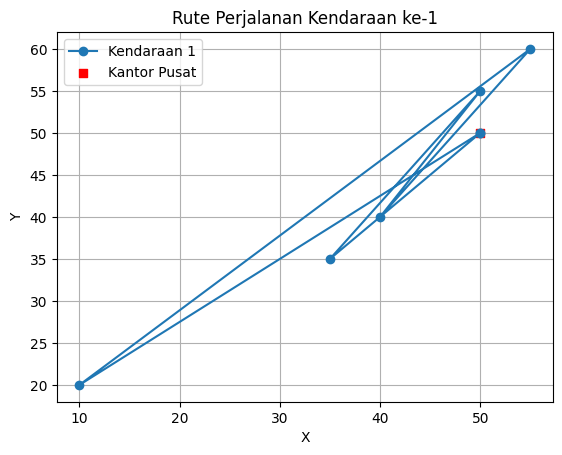

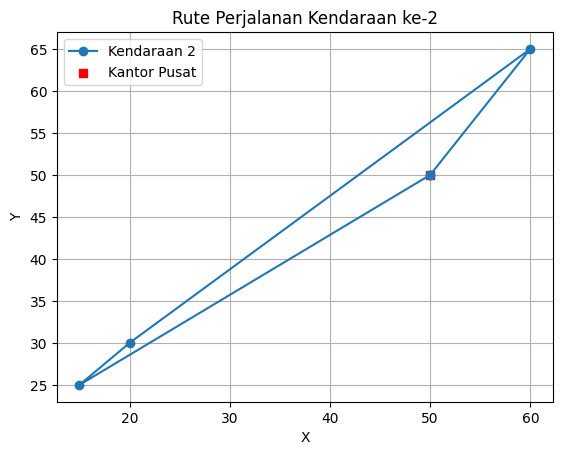

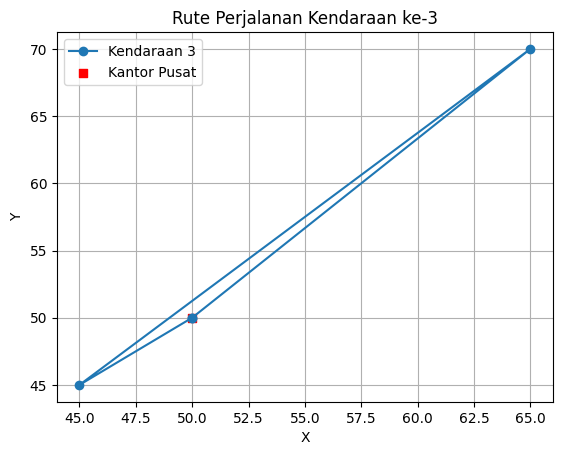

In [23]:
# buat list berisi 3 list yang akan menampung rute ketiga kendaraan
route_coords = [[], [], []]

# lakukan loop sebanyak kendaraan yang perusahaan miliki
for i in range(jumlahKendaraan):
    # kendaraan berasal dari kantor pusat dan akan kembali ke kantor pusat maka masukkan koordinat kantor pusat
    route_coords[i].append(kantorPusat)
    for cust in best_routes[i]:
        customer = cariPelanggan(cust, arrCust)
        coor = (customer[1], customer[2])
        route_coords[i].append(coor)

    # kendaraan berasal dari kantor pusat dan akan kembali ke kantor pusat maka masukkan koordinat kantor pusat
    route_coords[i].append(kantorPusat)

# lakukan enumerate untuk semua koordinat rute kendaraan
for i, route in enumerate(route_coords):
  # buat figure baru untuk setiap rute kendaraan
  plt.figure()

  # lakukan transpos rute dengan zip()
  x, y = zip(*route)

  # buat plot untuk koordinat rutenya
  plt.plot(x, y, marker='o', label=f'Kendaraan {i+1}')

  # tandai kantor pusat
  plt.scatter(kantorPusat[0], kantorPusat[1], c='red', marker='s', label='Kantor Pusat')

  plt.title(f'Rute Perjalanan Kendaraan ke-{i+1}')
  plt.xlabel('X')
  plt.ylabel('Y')
  plt.legend()
  plt.grid(True)
  plt.show()

# Penjelasan

**Bagian Pertama: Inisialisasi Data**

Kode ini diawali dengan menetapkan koordinat kantor pusat. Koordinat tersebut disimpan dalam bentuk tupple dengan nilai X = 50 dan Y = 50. Maka dari itu kantor pusat berada tepat di titik tengah koordinat.

Selanjutnya ada data pelanggan yang disusun dalam bentuk list berisi beberapa tupple. Setiap tupple memuat 4 informasi: ID pelanggan, koordinat X, koordinat Y, dan jumlah permintaan barang. Misalnya saja pelanggan dengan ID Cust-1001 berada di koordinat (10, 20) dengan permintaan sebanyak 10 unit.

Kemudian ditetapkan jumlah kendaraan sebanyak 3 unit dan kapasitas maksimum setiap kendaraan sebanyak 100 unit. Ini berarti setiap mobil atau truk hanya boleh mengangkut maksimal 100 unit barang dalam satu perjalanan.

**Bagian Kedua: Pemanggilan Fungsi Optimasi**

Setelah data siap, kode tersebut memanggil fungsi `simulated_annealing()` untuk mencari rute perjalanan paling optimal. Fungsi ini menerima 4 parameter: jumlah kendaraan, data pelanggan, kapasitas maksimum, dan koordinat kantor pusat. Hasilnya berupa dua nilai: `best_routes` yang berisi rute terbaik untuk setiap kendaraan, dan `best_distance` yang berisi total jarak tempuh seluruh rute tersebut.

**Bagian Ketiga: Menampilkan Rute dalam Teks**

Kode kemudian menampilkan hasil rute terbaik ke layar. Untuk setiap kendaraan, kode tersebut mencetak urutan kunjungan dimulai dari kantor pusat, kemudian ke pelanggan-pelanggan yang harus dikunjungi, dan kembali lagi ke kantor pusat. Formatnya seperti ini: kantor pusat - Cust-1001 - Cust-1002 - kantor pusat.

**Bagian Keempat: Visualisasi Rute dengan Grafik**

Terakhir, kode tersebut membuat visualisasi grafis untuk setiap rute kendaraan. Pertama-tama dibuat 3 list kosong untuk menampung koordinat perjalanan masing-masing kendaraan. Kemudian untuk setiap kendaraan:

- Koordinat kantor pusat dimasukkan sebagai titik awal
- Dilakukan pencarian data pelanggan berdasarkan ID yang ada di rute terbaik
- Koordinat X dan Y pelanggan tersebut diambil dan dimasukkan ke list
- Koordinat kantor pusat dimasukkan lagi sebagai titik akhir

Setelah semua koordinat terkumpul, kode tersebut membuat grafik untuk setiap kendaraan menggunakan matplotlib. Setiap grafik menampilkan garis rute perjalanan dengan titik-titik koordinat pelanggan, ditandai dengan marker lingkaran. Kantor pusat ditandai dengan kotak berwarna merah. Setiap grafik diberi judul sesuai nomor kendaraan dan dilengkapi dengan label sumbu X dan Y, legenda, serta garis bantu grid.

Contoh *output* <br>
**Output mungkin akan memberikan hasil yang berbeda karena dipilih secara acak** <br>
**Rute kendaraan 1**

<img src="./asset/Kendaraan_1.png" alt="Rute Kendaraan 1" style="width: 50%; height: auto;">

**Rute kendaraan 2**

<img src="./asset/Kendaraan_2.png" alt="Rute Kendaraan 2" style="width: 50%; height: auto;">

**Rute kendaraan 3**

<img src="./asset/Kendaraan_3.png" alt="Rute Kendaraan 3" style="width: 50%; height: auto;">
